In [2]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load only the usable columns from the USSC FY2025 dataset
usable_cols = [
    'SENTTOT', 'SMIN1', 'SMAX1', 'GLMIN', 'GLMAX',
    'AGE', 'AGECAT', 'NEWRACE', 'HISPORIG', 'MONSEX', 'NEWEDUC', 'CITIZEN',
    'DISTRICT', 'CIRCDIST', 'POOFFICE', 'ZONE', 'OFFGUIDE', 'DISPOSIT',
    'CRIMHIST', 'CRIMPTS', 'TOTCHPTS', 'XCRHISSR', 'WEAPON', 'DRUGMIN',
    'CASETYPE', 'NEWCNVTN', 'NOCOUNTS', 'NUMDEPEN',
    'SENTIMP', 'PRISDUM', 'PROBDUM', 'SUPRDUM'
]

df = pd.read_csv("data/raw/opafy25nid.csv", usecols=usable_cols, low_memory=False)
df.head()

,POOFFICE,ZONE,SENTTOT,AGE,AGECAT,CASETYPE,CIRCDIST,CITIZEN,CRIMHIST,CRIMPTS,...,SENTIMP,SUPRDUM,TOTCHPTS,WEAPON,XCRHISSR,DRUGMIN,GLMIN,GLMAX,SMIN1,SMAX1
0,1,D,48.00,41.0,6.0,1.0,47,1.0,1.0,0.0,...,1,1,0.0,0,1.0,120,46.0,57.0,120.0,9996.0
1,1,D,27.00,42.0,6.0,1.0,6,1.0,1.0,8.0,...,1,1,8.0,0,4.0,0,57.0,71.0,0.0,240.0
2,5,D,120.00,35.0,4.0,1.0,83,1.0,1.0,16.0,...,1,1,16.0,0,6.0,60,360.0,480.0,60.0,480.0
3,5,B,3.29,41.0,6.0,1.0,36,3.0,1.0,2.0,...,1,1,2.0,0,2.0,0,1.0,7.0,0.0,24.0
4,3,D,30.00,31.0,4.0,1.0,34,1.0,0.0,0.0,...,1,1,0.0,0,1.0,0,30.0,37.0,0.0,120.0


In [4]:
# Shape and basic info
print(f"Rows: {df.shape[0]}  |  Columns: {df.shape[1]}")
print(f"\nMissing values per column:")
print(df.isna().sum()[df.isna().sum() > 0])
print(f"\nSENTTOT (months) stats:")
df['SENTTOT'].describe()

Rows: 66662  |  Columns: 32

Missing values per column:
POOFFICE     129
ZONE         979
SENTTOT     5106
AGE          101
AGECAT       101
CASETYPE     822
CITIZEN      403
CRIMHIST    2507
CRIMPTS     4505
MONSEX       558
NEWEDUC     6365
NEWRACE     1489
NUMDEPEN    7165
TOTCHPTS    4482
XCRHISSR     715
GLMIN        681
GLMAX        681
SMIN1       1876
SMAX1       1876
dtype: int64

SENTTOT (months) stats:


count    61556.000000
mean        51.928262
std         80.521236
min          0.030000
25%          5.130000
50%         24.000000
75%         70.000000
max       3600.000000
Name: SENTTOT, dtype: float64

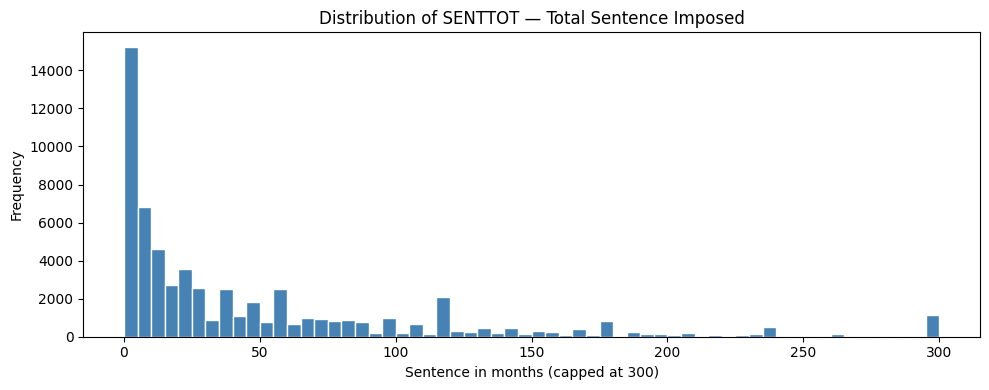

In [5]:
# Distribution of sentence length (target variable)
fig, ax = plt.subplots(figsize=(10, 4))
df['SENTTOT'].clip(upper=300).plot.hist(bins=60, ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel("Sentence in months (capped at 300)")
ax.set_title("Distribution of SENTTOT — Total Sentence Imposed")
plt.tight_layout()
plt.show()